# 05 主力收益分布与月度年化波动率

本 Notebook 复现论文 Figure 13、Table 7 与 Figure 14：构造无未来信息的主力连续收盘价，比较五个两年窗口的日收益经验分布与风险统计，并计算月内日收益标准差的年化值。

数据只从正式 silver 湖仓读取；所有结果仅保存在 Notebook 输出中，不写入 silver、gold 或其他数据文件。

## 在做什么

固定月份合约会到期，不能直接把某一合约的收盘价贯穿十年。本项每天使用上一交易日已经收盘的成交量信号选择下一交易日的主力合约，并在换月处用新旧合约最近共同有效收盘价的 log-gap 消除机械价格跳跃。

- Figure 13 风格图：六品种、五个两年窗口的平滑经验密度。
- Table 7 风格表：日收益样本标准差、5% 经验分位、无偏偏度与 Fisher 超额峰度。
- Figure 14 风格图：各自然月内日收益样本标准差乘以 sqrt(252)。

## 经济意义

日收益标准差和月度年化波动率描述价格风险的典型幅度；5% 分位描述较差交易日的左尾位置；偏度衡量左右尾不对称；超额峰度衡量相对正态分布的厚尾程度。分布变宽或左尾变深意味着短期风险增大，峰度上升意味着极端收益更常见。

这些量反映价格风险，不等同于流动性，也不能仅凭时间共变解释为算法交易、监管或 Level 2 数据开放的因果结果。

## 论文口径

论文按 2012–13、2014–15、2016–17、2018–19、2020–21 五个窗口展示主力合约日收益的经验分布，并在相同窗口报告标准差、5% Value at Risk、偏度和峰度。原表中的 VaR 保留负号，因此这里把它实现为收益的经验 5% 分位，而不是取正的损失金额。

论文 Figure 14 将每个自然月内的日收益标准差按 sqrt(252) 年化。论文没有完整披露主力换月算法；为避免前视和换月伪跳跃，本 Notebook 采用本项目当前已定义的主力连续规则。

## 主力连续规则与适用边界

- 信号日只使用当日收盘后可知的成交量，决定下一品种交易日的主力。
- 首次选择按成交量降序；并列时依次按持仓量降序、退市日升序、合约代码升序。
- 后续只允许退市日更晚的合约挑战，不允许回滚到更早到期合约；挑战者成交量必须严格大于现主力的 1.10 倍。
- 现主力下一交易日不再活跃时转到成交量最大的有效后月合约；若不存在后月候选，则结束当前连续片段，后续重新启动。
- 换月 gap 等于共同锚点上 log(新合约收盘价) 减 log(旧合约收盘价)。共同锚点优先是信号日，否则向前寻找最近的共同有效日；gap 不跨连续片段。
- 前复权与后复权 log 价格只相差片段内常数，因此日 log 收益应完全一致。本项用前复权收益做统计，并显式验证两者相等。
- 为建立样本起点的主力状态，读取截至分析结束日的可用前置历史，再把最终收益裁剪到研究日期。

## 统计约定

- 日收益：前复权 log 收盘价的一阶差分，只在同一品种、同一连续片段内计算。
- 标准差：样本标准差，ddof=1。
- VaR 5%：线性插值的经验 5% 分位，按论文保留负号。
- 偏度：有限样本无偏校正，bias=False。
- 峰度：Fisher 超额峰度，正态分布基准为 0，并使用有限样本无偏校正。
- 两年窗口只有覆盖两个日历年时才进入 Figure 13 和 Table 7；因此 NI 的不完整上市窗口不报告。
- 月度年化波动率：月内日收益样本标准差乘 sqrt(252)，少于两个有效日收益的月份不报告。

## 代码步骤

1. 定位项目根目录并导入三张权威 Schema。
2. 设置论文样本、两年窗口、换月阈值和六品种。
3. 契约化读取品种日历、合约日历和日线必要列。
4. 折叠 Session，并按前一交易日信号构造主力映射与共同锚点 gap。
5. 构造前、后复权 log 收盘价和日收益，输出覆盖表。
6. 绘制 Figure 13 风格收益密度并生成 Table 7 风格统计表。
7. 计算月度年化波动率并绘制 Figure 14 风格图。
8. 复算主力时序、换月方向、gap、收益、统计量和图表结构。

## 第 1 步：环境、根目录和权威 Schema

In [1]:
from __future__ import annotations

import math
import pathlib
import sys
from datetime import date

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
from IPython.display import display
from scipy.stats import gaussian_kde, kurtosis, skew

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()  # 当前工作目录

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        break
else:
    raise RuntimeError("未找到项目根目录")

PROJECT_ROOT = candidate_root

from config.data_contracts import (  # noqa: E402
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_DAILY_SCHEMA,
    FUTURES_VARIETY_CALENDAR_SCHEMA,
    arrow_to_pandas,
)
from config.settings import settings  # noqa: E402

print(f"project_root: {PROJECT_ROOT}")
print(f"python: {sys.executable}")
print(
    "schema_tables: "
    f"{FUTURES_VARIETY_CALENDAR_SCHEMA.metadata[b'table_name'].decode('utf-8')}, "
    f"{FUTURES_CONTRACT_CALENDAR_SCHEMA.metadata[b'table_name'].decode('utf-8')}, "
    f"{FUTURES_DAILY_SCHEMA.metadata[b'table_name'].decode('utf-8')}"
)

project_root: E:\Latitude_Analytics_v2
python: E:\anaconda3\envs\latitude\python.exe
schema_tables: dim_futures_variety_calendar, dim_futures_contract_calendar, fact_futures_daily


## 第 2 步：设置论文样本与统计参数

日期可以扩展到湖仓全历史。主力状态使用分析结束日以前的全部可用历史建立；展示和统计仍只取分析日期。

In [2]:
PAPER_START_DATE = date(2012, 1, 1)
PAPER_END_DATE = date(2021, 12, 31)
ANALYSIS_START_DATE: date | None = PAPER_START_DATE
ANALYSIS_END_DATE: date | None = PAPER_END_DATE
ROLL_TRIGGER_RATIO = 1.10
ANNUALIZATION_DAYS = 252
KDE_GRID_POINTS = 400

RETURN_PERIODS = [
    {"label": "2012-13", "start_year": 2012, "end_year": 2013},
    {"label": "2014-15", "start_year": 2014, "end_year": 2015},
    {"label": "2016-17", "start_year": 2016, "end_year": 2017},
    {"label": "2018-19", "start_year": 2018, "end_year": 2019},
    {"label": "2020-21", "start_year": 2020, "end_year": 2021},
]
PERIOD_LABELS = [period["label"] for period in RETURN_PERIODS]
PERIOD_BY_YEAR = {
    year: period["label"]
    for period in RETURN_PERIODS
    for year in range(period["start_year"], period["end_year"] + 1)
}
EXPECTED_YEARS_BY_PERIOD = {
    period["label"]: tuple(range(period["start_year"], period["end_year"] + 1))
    for period in RETURN_PERIODS
}

PRODUCTS = [
    {"exchange_code": "XSGE", "underlying_code": "RB", "label": "Steel Rebar"},
    {"exchange_code": "XSGE", "underlying_code": "CU", "label": "Copper"},
    {"exchange_code": "XSGE", "underlying_code": "NI", "label": "Nickel"},
    {"exchange_code": "XDCE", "underlying_code": "M", "label": "Soybean Meal"},
    {"exchange_code": "XDCE", "underlying_code": "L", "label": "Plastic"},
    {"exchange_code": "XDCE", "underlying_code": "C", "label": "Corn"},
]
PRODUCT_KEYS = [
    (product["exchange_code"], product["underlying_code"])
    for product in PRODUCTS
]
PRODUCT_LABEL_BY_KEY = {
    (product["exchange_code"], product["underlying_code"]): product["label"]
    for product in PRODUCTS
}
PRODUCT_COLORS = {
    ("XSGE", "RB"): "#3568B8",
    ("XSGE", "CU"): "#E4572E",
    ("XSGE", "NI"): "#F3A712",
    ("XDCE", "M"): "#2E8B57",
    ("XDCE", "L"): "#B23AEE",
    ("XDCE", "C"): "#1E9ACD",
}
PERIOD_COLORS = {
    "2012-13": "#F2B134",
    "2014-15": "#F05A28",
    "2016-17": "#D94F9D",
    "2018-19": "#5B2A86",
    "2020-21": "#1F1F1F",
}

if ROLL_TRIGGER_RATIO <= 1:
    raise ValueError("ROLL_TRIGGER_RATIO 必须大于 1")
if ANALYSIS_START_DATE is not None and ANALYSIS_END_DATE is not None:
    if ANALYSIS_START_DATE > ANALYSIS_END_DATE:
        raise ValueError("分析起始日不得晚于结束日")

display(pd.DataFrame(PRODUCTS))
print(f"analysis_dates: {ANALYSIS_START_DATE} to {ANALYSIS_END_DATE}")
print(f"roll_trigger_ratio: {ROLL_TRIGGER_RATIO:.2f}")
print(f"return_periods: {PERIOD_LABELS}")

,exchange_code,underlying_code,label
0,XSGE,RB,Steel Rebar
1,XSGE,CU,Copper
2,XSGE,NI,Nickel
3,XDCE,M,Soybean Meal
4,XDCE,L,Plastic
5,XDCE,C,Corn


analysis_dates: 2012-01-01 to 2021-12-31
roll_trigger_ratio: 1.10
return_periods: ['2012-13', '2014-15', '2016-17', '2018-19', '2020-21']


## 第 3 步：契约化读取三张 silver 表

从 Schema metadata 取得表名和 Hive 分区列，逐字段核对 Arrow 类型。查询只下推六品种和分析结束日；不设置读取起始日，以保留样本开始前的主力状态与共同锚点历史。

In [3]:
SCHEMA_BY_ALIAS = {
    "variety": FUTURES_VARIETY_CALENDAR_SCHEMA,
    "contract": FUTURES_CONTRACT_CALENDAR_SCHEMA,
    "daily": FUTURES_DAILY_SCHEMA,
}
COLUMNS_BY_ALIAS = {
    "variety": ["exchange_code", "underlying_code", "trading_date"],
    "contract": [
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "delist_date",
        "session_number",
    ],
    "daily": [
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "close",
        "volume",
        "open_interest",
        "has_market_data",
    ],
}

metadata_by_alias = {}
path_by_alias = {}
dataset_by_alias = {}
required_schema_by_alias = {}
for table_alias, authoritative_schema in SCHEMA_BY_ALIAS.items():
    table_metadata = {
        key.decode("utf-8"): value.decode("utf-8")
        for key, value in (authoritative_schema.metadata or {}).items()
    }
    table_path = settings.futures_lake_root / "silver" / table_metadata["table_name"]
    if not table_path.exists():
        raise FileNotFoundError(f"silver 表不存在：{table_path}")
    partition_columns = table_metadata["partition_columns"].split(",")
    partitioning_schema = pa.schema(
        [
            pa.field(column_name, authoritative_schema.field(column_name).type)
            for column_name in partition_columns
        ]
    )
    source_dataset = ds.dataset(
        table_path,
        format="parquet",
        partitioning=ds.partitioning(partitioning_schema, flavor="hive"),
    )
    required_schema = pa.schema(
        [
            authoritative_schema.field(column_name)
            for column_name in COLUMNS_BY_ALIAS[table_alias]
        ]
    )
    for expected_field in required_schema:
        actual_field = source_dataset.schema.field(expected_field.name)
        if actual_field.type != expected_field.type:
            raise TypeError(
                f"{table_alias}.{expected_field.name} 类型不匹配："
                f"期望 {expected_field.type}，实际 {actual_field.type}"
            )
    metadata_by_alias[table_alias] = table_metadata
    path_by_alias[table_alias] = table_path
    dataset_by_alias[table_alias] = source_dataset
    required_schema_by_alias[table_alias] = required_schema

product_filter = None
for exchange_code, underlying_code in PRODUCT_KEYS:
    current_product_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("underlying_code") == underlying_code)
    )
    product_filter = (
        current_product_filter
        if product_filter is None
        else product_filter | current_product_filter
    )

filter_expression = product_filter
if ANALYSIS_END_DATE is not None:
    filter_expression = filter_expression & (
        ds.field("trading_date") <= pa.scalar(ANALYSIS_END_DATE)
    )

source_df_by_alias = {}
for table_alias in SCHEMA_BY_ALIAS:
    selected_table = dataset_by_alias[table_alias].to_table(
        columns=COLUMNS_BY_ALIAS[table_alias],
        filter=filter_expression,
    )
    source_df_by_alias[table_alias] = arrow_to_pandas(
        selected_table,
        required_schema_by_alias[table_alias],
    )

source_variety_df = source_df_by_alias["variety"]
source_contract_session_df = source_df_by_alias["contract"]
source_daily_df = source_df_by_alias["daily"]
for source_df in [source_variety_df, source_contract_session_df, source_daily_df]:
    source_df["trading_date"] = pd.to_datetime(source_df["trading_date"])
source_contract_session_df["delist_date"] = pd.to_datetime(
    source_contract_session_df["delist_date"]
)
for numeric_column in ["close", "volume", "open_interest"]:
    source_daily_df[numeric_column] = pd.to_numeric(
        source_daily_df[numeric_column], errors="coerce"
    ).astype(float)

for table_alias in SCHEMA_BY_ALIAS:
    print(f"{table_alias}_path: {path_by_alias[table_alias]}")
    print(f"{table_alias}_rows: {len(source_df_by_alias[table_alias]):,}")

variety_path: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake\silver\dim_futures_variety_calendar
variety_rows: 16,236
contract_path: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake\silver\dim_futures_contract_calendar
contract_rows: 586,088
daily_path: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake\silver\fact_futures_daily
daily_rows: 165,548


## 第 4 步：构造无未来信息的主力映射

先确认同一合约日的多个 Session 具有唯一退市日，再折叠为一行并与日线一对一连接。下面的循环按品种交易日顺序直接实现项目现有选择规则；不导入可能触发交互入口的现有 Notebook 或 Python 导出。

In [4]:
product_date_keys = ["exchange_code", "underlying_code", "trading_date"]
contract_day_keys = [
    "exchange_code",
    "underlying_code",
    "contract_code",
    "trading_date",
]
calendar_delist_count_df = (
    source_contract_session_df.groupby(
        contract_day_keys,
        observed=True,
        dropna=False,
    )["delist_date"]
    .nunique(dropna=False)
    .reset_index(name="distinct_delist_dates")
)
calendar_delist_conflicts_df = calendar_delist_count_df.loc[
    calendar_delist_count_df["distinct_delist_dates"] != 1
]
if not calendar_delist_conflicts_df.empty:
    raise ValueError(
        "同一合约日存在缺失或冲突 delist_date："
        f"{len(calendar_delist_conflicts_df):,} 个键"
    )

contract_calendar_df = (
    source_contract_session_df.sort_values(
        [*contract_day_keys, "session_number"]
    )
    .drop_duplicates(contract_day_keys, keep="first")
    .drop(columns="session_number")
    .reset_index(drop=True)
)
if source_daily_df.duplicated(contract_day_keys).any():
    raise AssertionError("日线事实表在合约日键上存在重复")
if contract_calendar_df.duplicated(contract_day_keys).any():
    raise AssertionError("合约日历折叠后仍有重复键")

candidate_history_df = source_daily_df.merge(
    contract_calendar_df,
    on=contract_day_keys,
    how="left",
    validate="one_to_one",
    indicator=True,
)
unmatched_daily_df = candidate_history_df.loc[
    candidate_history_df["_merge"] != "both"
]
if not unmatched_daily_df.empty:
    raise ValueError(f"日线记录缺少合约日历匹配：{len(unmatched_daily_df):,} 行")
candidate_history_df = candidate_history_df.drop(columns="_merge")
if (candidate_history_df["volume"].dropna() < 0).any():
    raise ValueError("来源日线存在负成交量")

variety_dates_df = (
    source_variety_df[product_date_keys]
    .drop_duplicates()
    .sort_values(product_date_keys)
    .reset_index(drop=True)
)

mapping_records = []
for (exchange_code, underlying_code), product_dates_df in variety_dates_df.groupby(
    ["exchange_code", "underlying_code"],
    sort=True,
    observed=True,
):
    trading_dates = sorted(product_dates_df["trading_date"].tolist())
    product_history_df = candidate_history_df.loc[
        (candidate_history_df["exchange_code"] == exchange_code)
        & (candidate_history_df["underlying_code"] == underlying_code)
    ].copy()
    product_contract_calendar_df = contract_calendar_df.loc[
        (contract_calendar_df["exchange_code"] == exchange_code)
        & (contract_calendar_df["underlying_code"] == underlying_code)
    ].copy()
    delist_lookup = (
        product_contract_calendar_df.groupby("contract_code", observed=True)[
            "delist_date"
        ]
        .max()
        .to_dict()
    )
    active_codes_by_date = {
        trading_date: set(product_day_df["contract_code"].astype(str))
        for trading_date, product_day_df in product_contract_calendar_df.groupby(
            "trading_date", observed=True
        )
    }

    ranked_history_df = product_history_df.loc[
        product_history_df["has_market_data"].fillna(False)
        & product_history_df["volume"].notna()
        & (product_history_df["volume"] > 0)
    ].copy()
    ranked_history_df["open_interest_rank"] = pd.to_numeric(
        ranked_history_df["open_interest"], errors="coerce"
    ).fillna(-math.inf)
    ranked_history_df = ranked_history_df.sort_values(
        [
            "trading_date",
            "volume",
            "open_interest_rank",
            "delist_date",
            "contract_code",
        ],
        ascending=[True, False, False, True, True],
        kind="mergesort",
    ).drop(columns="open_interest_rank")
    ranked_candidates_by_date = {
        trading_date: product_day_df.to_dict("records")
        for trading_date, product_day_df in ranked_history_df.groupby(
            "trading_date", sort=False, observed=True
        )
    }

    main_contract_code = None
    continuity_segment = 0
    for signal_index, signal_trading_date in enumerate(trading_dates[:-1]):
        trading_date = trading_dates[signal_index + 1]
        ranked_candidates = ranked_candidates_by_date.get(signal_trading_date, [])
        target_active_codes = active_codes_by_date.get(trading_date, set())
        eligible_candidates = [
            candidate
            for candidate in ranked_candidates
            if str(candidate["contract_code"]) in target_active_codes
        ]

        previous_main_contract_code = main_contract_code
        incumbent_signal_volume = None
        challenger_contract_code = None
        challenger_signal_volume = None

        if main_contract_code is None:
            if not eligible_candidates:
                continue
            continuity_segment += 1
            main_contract_code = str(eligible_candidates[0]["contract_code"])
            selection_reason = "bootstrap_previous_day_volume_leader"
            other_candidates = [
                candidate
                for candidate in eligible_candidates
                if str(candidate["contract_code"]) != main_contract_code
            ]
            if other_candidates:
                challenger_contract_code = str(other_candidates[0]["contract_code"])
                challenger_signal_volume = float(other_candidates[0]["volume"])
        else:
            incumbent_candidate = next(
                (
                    candidate
                    for candidate in ranked_candidates
                    if str(candidate["contract_code"]) == main_contract_code
                ),
                None,
            )
            if incumbent_candidate is not None:
                incumbent_signal_volume = float(incumbent_candidate["volume"])

            incumbent_delist_date = delist_lookup.get(main_contract_code)
            challenger_candidates = [
                candidate
                for candidate in eligible_candidates
                if str(candidate["contract_code"]) != main_contract_code
                and (
                    incumbent_delist_date is None
                    or (
                        pd.notna(candidate["delist_date"])
                        and candidate["delist_date"] > incumbent_delist_date
                    )
                )
            ]
            if challenger_candidates:
                challenger_contract_code = str(
                    challenger_candidates[0]["contract_code"]
                )
                challenger_signal_volume = float(challenger_candidates[0]["volume"])

            if main_contract_code not in target_active_codes:
                if challenger_contract_code is None:
                    main_contract_code = None
                    continue
                main_contract_code = challenger_contract_code
                selection_reason = "incumbent_not_active_next_trading_date"
            elif incumbent_signal_volume is None:
                if challenger_contract_code is None:
                    selection_reason = "no_valid_volume_keep_incumbent"
                else:
                    main_contract_code = challenger_contract_code
                    selection_reason = "incumbent_market_data_missing"
            elif (
                challenger_signal_volume is not None
                and challenger_signal_volume
                > incumbent_signal_volume * ROLL_TRIGGER_RATIO
            ):
                main_contract_code = challenger_contract_code
                selection_reason = "challenger_volume_threshold"
            else:
                selection_reason = "incumbent_retained"

        selected_candidate = next(
            (
                candidate
                for candidate in ranked_candidates
                if str(candidate["contract_code"]) == main_contract_code
            ),
            None,
        )
        main_contract_signal_volume = (
            None if selected_candidate is None else float(selected_candidate["volume"])
        )
        is_roll = (
            previous_main_contract_code is not None
            and main_contract_code != previous_main_contract_code
        )
        roll_anchor_date = pd.NaT
        previous_contract_anchor_close = np.nan
        main_contract_anchor_close = np.nan
        roll_log_gap = np.nan
        if is_roll:
            pair_history_df = product_history_df.loc[
                (product_history_df["trading_date"] <= signal_trading_date)
                & product_history_df["contract_code"].isin(
                    [previous_main_contract_code, main_contract_code]
                )
                & product_history_df["has_market_data"].fillna(False)
                & product_history_df["close"].notna()
                & (product_history_df["close"] > 0),
                ["trading_date", "contract_code", "close"],
            ].drop_duplicates(["trading_date", "contract_code"], keep="last")
            close_matrix_df = pair_history_df.pivot(
                index="trading_date", columns="contract_code", values="close"
            )
            required_contract_codes = [
                previous_main_contract_code,
                main_contract_code,
            ]
            if any(
                contract_code not in close_matrix_df.columns
                for contract_code in required_contract_codes
            ):
                raise ValueError(
                    "换月缺少共同有效收盘价："
                    f"{previous_main_contract_code} -> {main_contract_code}, "
                    f"signal_trading_date={signal_trading_date.date()}"
                )
            overlap_df = close_matrix_df[required_contract_codes].dropna()
            if overlap_df.empty:
                raise ValueError(
                    "换月缺少共同有效收盘价："
                    f"{previous_main_contract_code} -> {main_contract_code}, "
                    f"signal_trading_date={signal_trading_date.date()}"
                )
            roll_anchor_date = overlap_df.index.max()
            previous_contract_anchor_close = float(
                overlap_df.loc[roll_anchor_date, previous_main_contract_code]
            )
            main_contract_anchor_close = float(
                overlap_df.loc[roll_anchor_date, main_contract_code]
            )
            roll_log_gap = math.log(main_contract_anchor_close) - math.log(
                previous_contract_anchor_close
            )

        mapping_records.append(
            {
                "exchange_code": exchange_code,
                "underlying_code": underlying_code,
                "trading_date": trading_date,
                "main_contract_code": main_contract_code,
                "signal_trading_date": signal_trading_date,
                "continuity_segment": continuity_segment,
                "previous_main_contract_code": previous_main_contract_code,
                "challenger_contract_code": challenger_contract_code,
                "main_contract_signal_volume": main_contract_signal_volume,
                "incumbent_signal_volume": incumbent_signal_volume,
                "challenger_signal_volume": challenger_signal_volume,
                "is_roll": is_roll,
                "selection_reason": selection_reason,
                "roll_anchor_date": roll_anchor_date,
                "previous_contract_anchor_close": previous_contract_anchor_close,
                "main_contract_anchor_close": main_contract_anchor_close,
                "roll_log_gap": roll_log_gap,
            }
        )

main_mapping_df = pd.DataFrame(mapping_records).sort_values(
    ["exchange_code", "underlying_code", "trading_date"]
).reset_index(drop=True)
if main_mapping_df.empty:
    raise ValueError("没有生成主力映射")
if main_mapping_df.duplicated(product_date_keys).any():
    raise AssertionError("主力映射主键重复")
print(f"calendar_delist_conflicts: {len(calendar_delist_conflicts_df):,}")
print(f"candidate_contract_days: {len(candidate_history_df):,}")
print(f"main_mapping_rows: {len(main_mapping_df):,}")
print(f"rolls: {int(main_mapping_df['is_roll'].sum()):,}")

calendar_delist_conflicts: 0
candidate_contract_days: 165,548
main_mapping_rows: 16,230
rolls: 326


## 第 5 步：构造连续 log 收盘价、日收益和覆盖表

先把映射连接到被选合约的当日收盘价，再在每个连续片段内累计换月 gap。前复权以最新端为锚，后复权以最早端为锚；样本收益在完整历史上计算后才裁剪日期。

In [5]:
selected_daily_df = source_daily_df[
    [
        "exchange_code",
        "underlying_code",
        "trading_date",
        "contract_code",
        "close",
        "has_market_data",
    ]
].rename(columns={"contract_code": "main_contract_code"})
selected_daily_df = selected_daily_df.drop_duplicates(
    [*product_date_keys, "main_contract_code"], keep="last"
)
continuous_df = main_mapping_df.merge(
    selected_daily_df,
    on=[*product_date_keys, "main_contract_code"],
    how="left",
    validate="one_to_one",
)
continuous_df["has_market_data"] = (
    continuous_df["has_market_data"].fillna(False).astype(bool)
)
continuous_df["close"] = pd.to_numeric(
    continuous_df["close"], errors="coerce"
)
invalid_effective_close_mask = continuous_df["has_market_data"] & (
    continuous_df["close"].isna() | (continuous_df["close"] <= 0)
)
if invalid_effective_close_mask.any():
    raise ValueError("有效主力行情存在非正或缺失收盘价，无法取 log")
valid_close_mask = (
    continuous_df["has_market_data"]
    & continuous_df["close"].notna()
    & (continuous_df["close"] > 0)
)
continuous_df["log_close"] = np.nan
continuous_df.loc[valid_close_mask, "log_close"] = np.log(
    continuous_df.loc[valid_close_mask, "close"].astype(float)
)

segment_keys = ["exchange_code", "underlying_code", "continuity_segment"]
continuous_df = continuous_df.sort_values(
    [*segment_keys, "trading_date"]
).reset_index(drop=True)
continuous_df["forward_log_adjustment"] = 0.0
continuous_df["backward_log_adjustment"] = 0.0
for _, segment_df in continuous_df.groupby(
    segment_keys, sort=True, observed=True
):
    segment_index = segment_df.index
    roll_gap_array = pd.to_numeric(
        segment_df["roll_log_gap"], errors="coerce"
    ).fillna(0.0).to_numpy(dtype=float)
    cumulative_gap_array = np.cumsum(roll_gap_array)
    continuous_df.loc[segment_index, "backward_log_adjustment"] = (
        -cumulative_gap_array
    )
    continuous_df.loc[segment_index, "forward_log_adjustment"] = (
        roll_gap_array.sum() - cumulative_gap_array
    )

continuous_df["forward_adjusted_log_close"] = (
    continuous_df["log_close"] + continuous_df["forward_log_adjustment"]
)
continuous_df["backward_adjusted_log_close"] = (
    continuous_df["log_close"] + continuous_df["backward_log_adjustment"]
)
continuous_df["forward_log_return"] = continuous_df.groupby(
    segment_keys, observed=True
)["forward_adjusted_log_close"].diff()
continuous_df["backward_log_return"] = continuous_df.groupby(
    segment_keys, observed=True
)["backward_adjusted_log_close"].diff()

sample_mask = pd.Series(True, index=continuous_df.index)
if ANALYSIS_START_DATE is not None:
    sample_mask &= continuous_df["trading_date"] >= pd.Timestamp(ANALYSIS_START_DATE)
if ANALYSIS_END_DATE is not None:
    sample_mask &= continuous_df["trading_date"] <= pd.Timestamp(ANALYSIS_END_DATE)
sample_continuous_df = continuous_df.loc[sample_mask].copy()
sample_continuous_df["period"] = sample_continuous_df["trading_date"].dt.year.map(
    PERIOD_BY_YEAR
)
sample_returns_df = sample_continuous_df.dropna(
    subset=["forward_log_return"]
).copy()
sample_returns_df["trading_year"] = sample_returns_df["trading_date"].dt.year

period_coverage_df = (
    sample_returns_df.dropna(subset=["period"])
    .groupby(
        ["exchange_code", "underlying_code", "period"],
        observed=True,
        as_index=False,
    )
    .agg(
        first_return_date=("trading_date", "min"),
        last_return_date=("trading_date", "max"),
        return_count=("forward_log_return", "size"),
        observed_years=("trading_year", lambda values: tuple(sorted(set(values)))),
    )
)
period_coverage_df["expected_years"] = period_coverage_df["period"].map(
    EXPECTED_YEARS_BY_PERIOD
)
period_coverage_df["is_complete_two_year_period"] = (
    period_coverage_df["observed_years"] == period_coverage_df["expected_years"]
)
complete_period_keys_df = period_coverage_df.loc[
    period_coverage_df["is_complete_two_year_period"],
    ["exchange_code", "underlying_code", "period"],
]
complete_period_returns_df = sample_returns_df.merge(
    complete_period_keys_df,
    on=["exchange_code", "underlying_code", "period"],
    how="inner",
    validate="many_to_one",
)

coverage_summary_df = (
    sample_continuous_df.groupby(
        ["exchange_code", "underlying_code"],
        observed=True,
        as_index=False,
    )
    .agg(
        first_main_date=("trading_date", "min"),
        last_main_date=("trading_date", "max"),
        main_mapping_days=("main_contract_code", "size"),
        valid_main_closes=("log_close", "count"),
        daily_returns=("forward_log_return", "count"),
        rolls=("is_roll", "sum"),
        continuity_segments=("continuity_segment", "nunique"),
    )
)
coverage_summary_df["label"] = coverage_summary_df.apply(
    lambda row: PRODUCT_LABEL_BY_KEY[(row["exchange_code"], row["underlying_code"])],
    axis=1,
)
coverage_summary_df = coverage_summary_df[
    [
        "exchange_code",
        "underlying_code",
        "label",
        "first_main_date",
        "last_main_date",
        "main_mapping_days",
        "valid_main_closes",
        "daily_returns",
        "rolls",
        "continuity_segments",
    ]
]
display(coverage_summary_df)
display(period_coverage_df)
print(f"sample_main_rows: {len(sample_continuous_df):,}")
print(f"sample_return_rows: {len(sample_returns_df):,}")
print(f"complete_period_return_rows: {len(complete_period_returns_df):,}")

,exchange_code,underlying_code,label,first_main_date,last_main_date,main_mapping_days,valid_main_closes,daily_returns,rolls,continuity_segments
0,XDCE,C,Corn,2012-01-04,2021-12-31,2431,2431,2431,31,1
1,XDCE,L,Plastic,2012-01-04,2021-12-31,2431,2431,2431,30,1
2,XDCE,M,Soybean Meal,2012-01-04,2021-12-31,2431,2431,2431,29,1
3,XSGE,CU,Copper,2012-01-04,2021-12-31,2431,2431,2431,119,1
4,XSGE,NI,Nickel,2015-03-30,2021-12-31,1650,1650,1649,40,1
5,XSGE,RB,Steel Rebar,2012-01-04,2021-12-31,2431,2431,2431,30,1


,exchange_code,underlying_code,period,first_return_date,last_return_date,return_count,observed_years,expected_years,is_complete_two_year_period
0,XDCE,C,2012-13,2012-01-04,2013-12-31,481,"(2012, 2013)","(2012, 2013)",True
1,XDCE,C,2014-15,2014-01-02,2015-12-31,489,"(2014, 2015)","(2014, 2015)",True
2,XDCE,C,2016-17,2016-01-04,2017-12-29,488,"(2016, 2017)","(2016, 2017)",True
3,XDCE,C,2018-19,2018-01-02,2019-12-31,487,"(2018, 2019)","(2018, 2019)",True
4,XDCE,C,2020-21,2020-01-02,2021-12-31,486,"(2020, 2021)","(2020, 2021)",True
5,XDCE,L,2012-13,2012-01-04,2013-12-31,481,"(2012, 2013)","(2012, 2013)",True
6,XDCE,L,2014-15,2014-01-02,2015-12-31,489,"(2014, 2015)","(2014, 2015)",True
7,XDCE,L,2016-17,2016-01-04,2017-12-29,488,"(2016, 2017)","(2016, 2017)",True
8,XDCE,L,2018-19,2018-01-02,2019-12-31,487,"(2018, 2019)","(2018, 2019)",True
9,XDCE,L,2020-21,2020-01-02,2021-12-31,486,"(2020, 2021)","(2020, 2021)",True


sample_main_rows: 13,805
sample_return_rows: 13,804
complete_period_return_rows: 13,616


## 第 6 步：Figure 13 风格收益经验分布

每条曲线使用同一两年窗口内的全部有效日收益做 Gaussian KDE。每个品种使用自身 0.5%–99.5% 分位形成对称横轴，避免单个极端值压缩主体；密度估计仍使用完整样本。

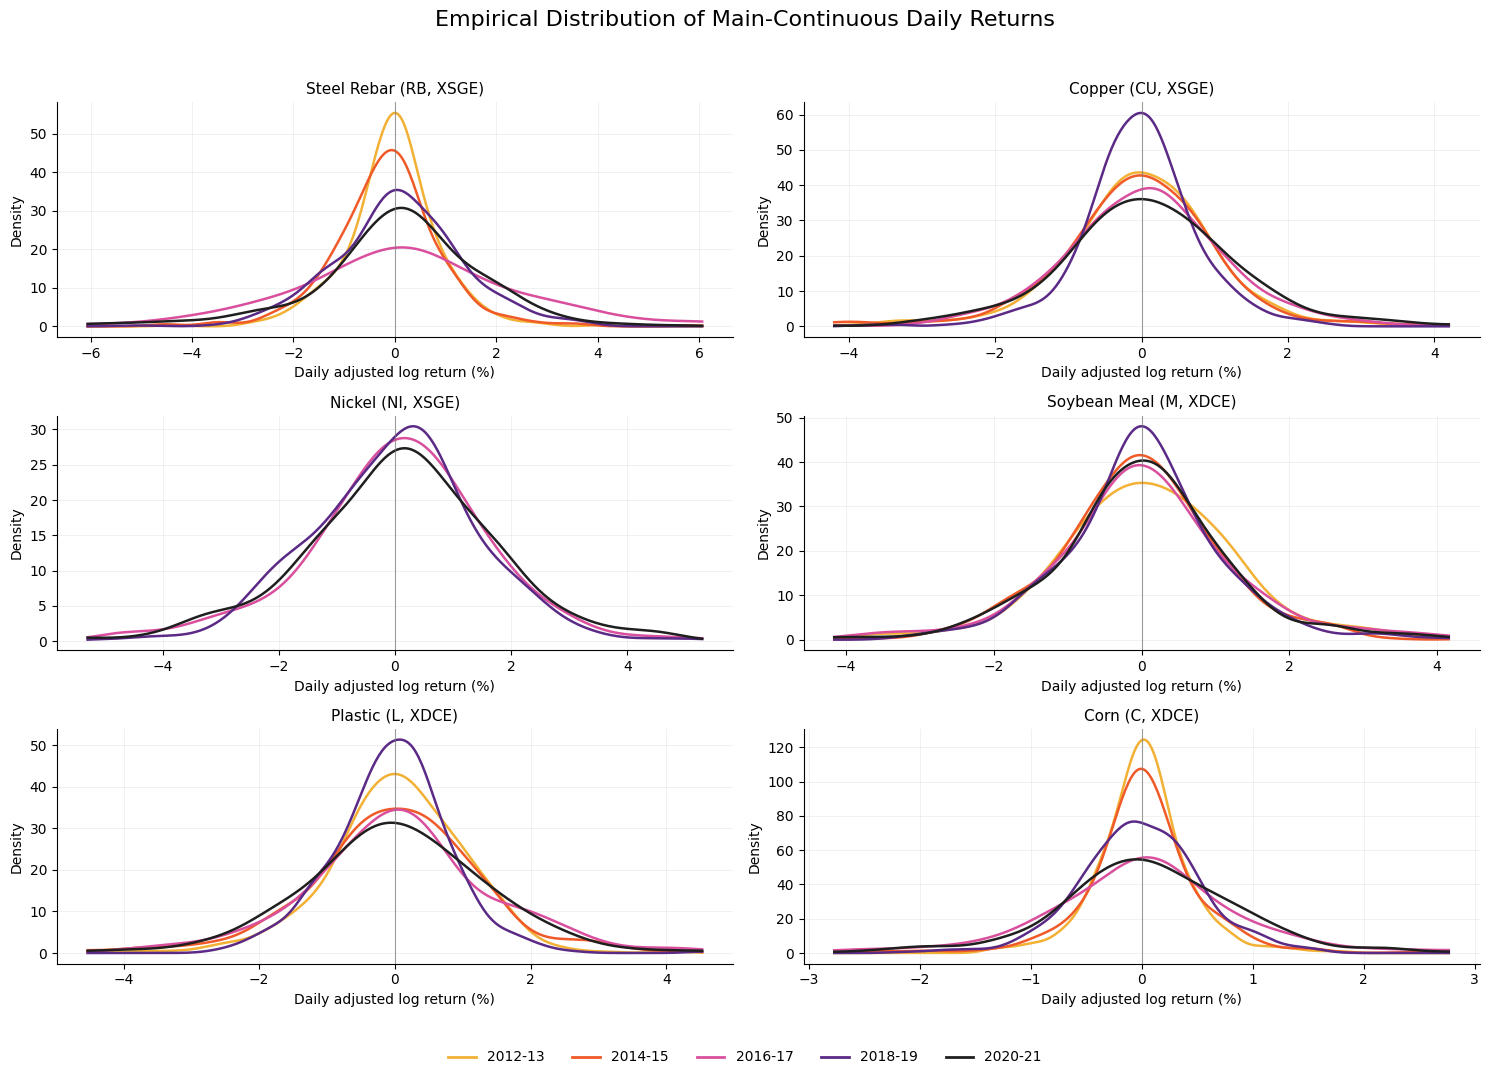

In [6]:
figure13, axes13 = plt.subplots(3, 2, figsize=(15, 11))
figure13_line_count_by_product = {}
for axis, product in zip(axes13.flat, PRODUCTS):
    product_key = (product["exchange_code"], product["underlying_code"])
    product_returns_df = complete_period_returns_df.loc[
        (complete_period_returns_df["exchange_code"] == product_key[0])
        & (complete_period_returns_df["underlying_code"] == product_key[1])
    ]
    if product_returns_df.empty:
        raise AssertionError(f"Figure 13 品种没有完整窗口：{product_key}")
    tail_limits = product_returns_df["forward_log_return"].quantile([0.005, 0.995])
    horizontal_limit = max(
        0.005,
        abs(float(tail_limits.iloc[0])),
        abs(float(tail_limits.iloc[1])),
    ) * 1.10
    return_grid = np.linspace(-horizontal_limit, horizontal_limit, KDE_GRID_POINTS)

    plotted_periods = 0
    for period_label in PERIOD_LABELS:
        period_return_array = product_returns_df.loc[
            product_returns_df["period"] == period_label,
            "forward_log_return",
        ].to_numpy(dtype=float)
        if len(period_return_array) < 3:
            continue
        if np.std(period_return_array, ddof=1) <= 0:
            raise AssertionError(f"收益窗口没有离散度：{product_key}, {period_label}")
        density = gaussian_kde(period_return_array)(return_grid)
        axis.plot(
            return_grid * 100,
            density,
            color=PERIOD_COLORS[period_label],
            linewidth=1.8,
            label=period_label,
        )
        plotted_periods += 1

    figure13_line_count_by_product[product_key] = plotted_periods
    axis.axvline(0, color="#777777", linewidth=0.8, alpha=0.7)
    axis.set_title(
        f"{product['label']} ({product['underlying_code']}, {product['exchange_code']})",
        fontsize=11,
    )
    axis.set_xlabel("Daily adjusted log return (%)")
    axis.set_ylabel("Density")
    axis.grid(alpha=0.2, linewidth=0.6)
    axis.spines[["top", "right"]].set_visible(False)

legend_handles = [
    Line2D([0], [0], color=PERIOD_COLORS[label], linewidth=2, label=label)
    for label in PERIOD_LABELS
]
figure13.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(PERIOD_LABELS),
    frameon=False,
    bbox_to_anchor=(0.5, 0.01),
)
figure13.suptitle("Empirical Distribution of Main-Continuous Daily Returns", fontsize=16)
figure13.tight_layout(rect=(0, 0.06, 1, 0.96))
plt.show()

## 第 7 步：Table 7 风格风险统计

数值对象保留小数收益单位；展示表把标准差和 5% 分位转成百分比。NI 只显示覆盖完整两个日历年的三个窗口。

In [7]:
return_statistic_records = []
for (exchange_code, underlying_code, period_label), period_returns_df in (
    complete_period_returns_df.groupby(
        ["exchange_code", "underlying_code", "period"],
        observed=True,
        sort=True,
    )
):
    return_array = period_returns_df["forward_log_return"].to_numpy(dtype=float)
    return_statistic_records.append(
        {
            "exchange_code": exchange_code,
            "underlying_code": underlying_code,
            "label": PRODUCT_LABEL_BY_KEY[(exchange_code, underlying_code)],
            "period": period_label,
            "n_returns": len(return_array),
            "standard_deviation": float(np.std(return_array, ddof=1)),
            "var_5pct": float(np.quantile(return_array, 0.05)),
            "skewness": float(skew(return_array, bias=False)),
            "excess_kurtosis": float(kurtosis(return_array, fisher=True, bias=False)),
        }
    )

return_statistics_df = pd.DataFrame(return_statistic_records)
return_statistics_df["period"] = pd.Categorical(
    return_statistics_df["period"], categories=PERIOD_LABELS, ordered=True
)
return_statistics_df = return_statistics_df.sort_values(
    ["exchange_code", "underlying_code", "period"]
).reset_index(drop=True)

table7_display_records = []
for product in PRODUCTS:
    product_statistics_df = return_statistics_df.loc[
        (return_statistics_df["exchange_code"] == product["exchange_code"])
        & (return_statistics_df["underlying_code"] == product["underlying_code"])
    ].set_index("period")
    for measure_label, column_name, formatter in [
        ("Std", "standard_deviation", lambda value: f"{value:.2%}"),
        ("VaR 5%", "var_5pct", lambda value: f"{value:.2%}"),
        ("Skewness", "skewness", lambda value: f"{value:.2f}"),
        ("Excess kurtosis", "excess_kurtosis", lambda value: f"{value:.2f}"),
    ]:
        display_record = {
            "Underlying": product["label"],
            "Measure": measure_label,
        }
        for period_label in PERIOD_LABELS:
            display_record[period_label] = (
                ""
                if period_label not in product_statistics_df.index
                else formatter(float(product_statistics_df.loc[period_label, column_name]))
            )
        table7_display_records.append(display_record)

table7_display_df = pd.DataFrame(table7_display_records).set_index(
    ["Underlying", "Measure"]
)
display(table7_display_df)

early_late_records = []
for product in PRODUCTS:
    product_statistics_df = return_statistics_df.loc[
        (return_statistics_df["exchange_code"] == product["exchange_code"])
        & (return_statistics_df["underlying_code"] == product["underlying_code"])
    ].sort_values("period")
    first_row = product_statistics_df.iloc[0]
    last_row = product_statistics_df.iloc[-1]
    early_late_records.append(
        {
            "label": product["label"],
            "first_period": str(first_row["period"]),
            "last_period": str(last_row["period"]),
            "std_change_pct_points": (
                last_row["standard_deviation"] - first_row["standard_deviation"]
            ) * 100,
            "var_5pct_change_pct_points": (
                last_row["var_5pct"] - first_row["var_5pct"]
            ) * 100,
            "excess_kurtosis_change": (
                last_row["excess_kurtosis"] - first_row["excess_kurtosis"]
            ),
        }
    )
early_late_comparison_df = pd.DataFrame(early_late_records)
display(early_late_comparison_df.round(3))
print(f"table7_product_periods: {len(return_statistics_df):,}")

2012-13 2014-15 2016-17 2018-19 2020-21
Underlying   Measure                                                
Steel Rebar  Std               0.91%   1.08%   2.28%   1.30%   1.69%
             VaR 5%           -1.62%  -1.84%  -3.56%  -2.08%  -2.91%
             Skewness          -0.10    0.13   -0.13   -0.34   -0.77
             Excess kurtosis    2.27    3.50    1.03    2.22    2.61
Copper       Std               1.05%   1.13%   1.20%   0.77%   1.31%
             VaR 5%           -1.61%  -1.72%  -1.71%  -1.24%  -2.02%
             Skewness          -0.12   -0.12    0.42   -0.32   -0.52
             Excess kurtosis    2.11    3.98    3.81    2.31    3.82
Nickel       Std                               1.60%   1.50%   1.67%
             VaR 5%                           -2.79%  -2.29%  -2.92%
             Skewness                          -0.35    0.41   -0.32
             Excess kurtosis                    1.51    2.17    1.18
Soybean Meal Std               1.20%   1.07%   1.28%   1.06%   1.19%
             VaR 5%           -1.75%  -1.85%  -1.92%  -1.61%  -1.88%
             Skewness           0.01    0.14    0.20    0.12    0.29
             Excess kurtosis    1.07    0.93    1.93    2.27    2.12
Plastic      Std               0.99%   1.30%   1.41%   0.85%   1.47%
             VaR 5%           -1.61%  -1.98%  -2.22%  -1.42%  -2.20%
             Skewness          -0.26   -0.00    0.04    0.19    0.27
             Excess kurtosis    1.25    2.64    1.19    1.78    3.00
Corn         Std               0.41%   0.57%   0.94%   0.54%   0.84%
             VaR 5%           -0.66%  -0.87%  -1.47%  -0.90%  -1.25%
             Skewness           0.28   -1.46    0.18   -0.15    0.03
             Excess kurtosis    2.31    9.41    2.41    0.91    1.52

,label,first_period,last_period,std_change_pct_points,var_5pct_change_pct_points,excess_kurtosis_change
0,Steel Rebar,2012-13,2020-21,0.781,-1.290,0.335
1,Copper,2012-13,2020-21,0.259,-0.409,1.703
2,Nickel,2016-17,2020-21,0.071,-0.122,-0.339
3,Soybean Meal,2012-13,2020-21,-0.006,-0.137,1.047
4,Plastic,2012-13,2020-21,0.481,-0.590,1.745
5,Corn,2012-13,2020-21,0.427,-0.597,-0.787


table7_product_periods: 28


## 第 8 步：Figure 14 风格月度年化波动率

每个自然月独立计算日收益样本标准差并乘 sqrt(252)。各品种保留自身纵轴范围，以便观察时间变化；纵轴单位统一为年化百分比。

,exchange_code,underlying_code,first_month,last_month,reported_months,median_annualized_volatility,maximum_annualized_volatility,label
0,XDCE,C,2012-01-01,2021-12-01,120,0.089415,0.240192,Corn
1,XDCE,L,2012-01-01,2021-12-01,120,0.176713,0.407647,Plastic
2,XDCE,M,2012-01-01,2021-12-01,120,0.170632,0.351298,Soybean Meal
3,XSGE,CU,2012-01-01,2021-12-01,120,0.153802,0.472730,Copper
4,XSGE,NI,2015-04-01,2021-12-01,81,0.243561,0.420789,Nickel
5,XSGE,RB,2012-01-01,2021-12-01,120,0.191750,0.627799,Steel Rebar


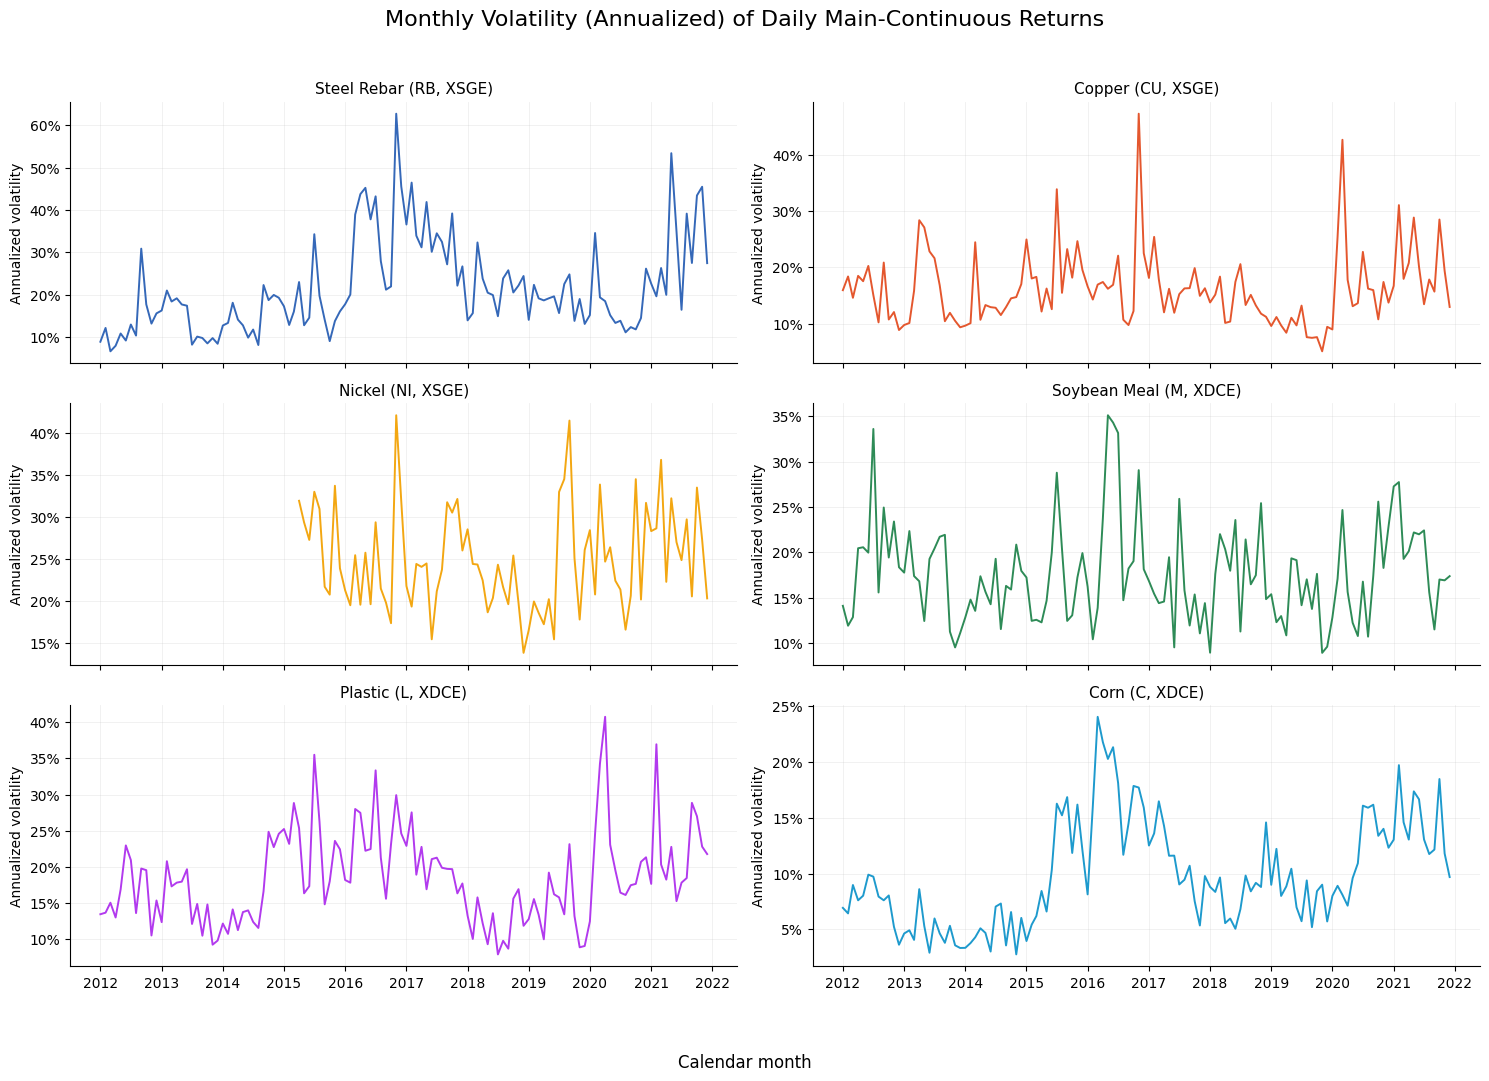

In [8]:
sample_returns_df["calendar_month"] = (
    sample_returns_df["trading_date"].dt.to_period("M").dt.to_timestamp()
)
monthly_volatility_df = (
    sample_returns_df.groupby(
        ["exchange_code", "underlying_code", "calendar_month"],
        observed=True,
        as_index=False,
    )
    .agg(
        return_count=("forward_log_return", "size"),
        monthly_daily_std=("forward_log_return", lambda values: values.std(ddof=1)),
    )
)
monthly_volatility_df["annualized_volatility"] = (
    monthly_volatility_df["monthly_daily_std"] * math.sqrt(ANNUALIZATION_DAYS)
)
monthly_volatility_df = monthly_volatility_df.loc[
    (monthly_volatility_df["return_count"] >= 2)
    & monthly_volatility_df["annualized_volatility"].notna()
].copy()

monthly_volatility_summary_df = (
    monthly_volatility_df.groupby(
        ["exchange_code", "underlying_code"],
        observed=True,
        as_index=False,
    )
    .agg(
        first_month=("calendar_month", "min"),
        last_month=("calendar_month", "max"),
        reported_months=("annualized_volatility", "size"),
        median_annualized_volatility=("annualized_volatility", "median"),
        maximum_annualized_volatility=("annualized_volatility", "max"),
    )
)
monthly_volatility_summary_df["label"] = monthly_volatility_summary_df.apply(
    lambda row: PRODUCT_LABEL_BY_KEY[(row["exchange_code"], row["underlying_code"])],
    axis=1,
)
display(monthly_volatility_summary_df)

figure14, axes14 = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
for axis, product in zip(axes14.flat, PRODUCTS):
    product_key = (product["exchange_code"], product["underlying_code"])
    product_monthly_df = monthly_volatility_df.loc[
        (monthly_volatility_df["exchange_code"] == product_key[0])
        & (monthly_volatility_df["underlying_code"] == product_key[1])
    ].sort_values("calendar_month")
    if product_monthly_df.empty:
        raise AssertionError(f"Figure 14 品种没有月度波动率：{product_key}")
    axis.plot(
        product_monthly_df["calendar_month"],
        product_monthly_df["annualized_volatility"] * 100,
        color=PRODUCT_COLORS[product_key],
        linewidth=1.4,
    )
    axis.set_title(
        f"{product['label']} ({product['underlying_code']}, {product['exchange_code']})",
        fontsize=11,
    )
    axis.set_ylabel("Annualized volatility")
    axis.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    axis.grid(alpha=0.2, linewidth=0.6)
    axis.spines[["top", "right"]].set_visible(False)

figure14.suptitle("Monthly Volatility (Annualized) of Daily Main-Continuous Returns", fontsize=16)
figure14.supxlabel("Calendar month", y=0.015)
figure14.tight_layout(rect=(0, 0.045, 1, 0.96))
plt.show()

## 验证

以下验证覆盖六品种数据、前一日信号邻接关系、禁止回滚、共同锚点公式、前后复权收益恒等、Table 7 每一格和月度年化公式，并检查两张图都有六个非空面板。

In [9]:
available_product_keys = set(
    sample_returns_df[["exchange_code", "underlying_code"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)
if available_product_keys != set(PRODUCT_KEYS):
    raise AssertionError("目标六品种收益覆盖不完整")
if not np.isfinite(sample_returns_df["forward_log_return"].to_numpy(dtype=float)).all():
    raise AssertionError("主力日收益包含非有限值")

adjacent_pairs_df = variety_dates_df.copy()
adjacent_pairs_df["expected_signal_trading_date"] = adjacent_pairs_df.groupby(
    ["exchange_code", "underlying_code"], observed=True
)["trading_date"].shift(1)
mapping_signal_check_df = main_mapping_df.merge(
    adjacent_pairs_df,
    on=product_date_keys,
    how="left",
    validate="one_to_one",
)
if mapping_signal_check_df["expected_signal_trading_date"].isna().any():
    raise AssertionError("主力映射缺少品种日历前一交易日")
if not (
    mapping_signal_check_df["signal_trading_date"]
    == mapping_signal_check_df["expected_signal_trading_date"]
).all():
    raise AssertionError("主力映射没有严格使用前一品种交易日信号")

contract_delist_lookup_df = (
    contract_calendar_df.groupby(
        ["exchange_code", "underlying_code", "contract_code"],
        observed=True,
        as_index=False,
    )["delist_date"]
    .max()
)
roll_direction_df = main_mapping_df.loc[main_mapping_df["is_roll"]].merge(
    contract_delist_lookup_df.rename(
        columns={
            "contract_code": "previous_main_contract_code",
            "delist_date": "previous_main_delist_date",
        }
    ),
    on=["exchange_code", "underlying_code", "previous_main_contract_code"],
    how="left",
    validate="many_to_one",
).merge(
    contract_delist_lookup_df.rename(
        columns={
            "contract_code": "main_contract_code",
            "delist_date": "main_delist_date",
        }
    ),
    on=["exchange_code", "underlying_code", "main_contract_code"],
    how="left",
    validate="many_to_one",
)
if roll_direction_df[["previous_main_delist_date", "main_delist_date"]].isna().any().any():
    raise AssertionError("换月方向验证缺少退市日")
if not (
    roll_direction_df["main_delist_date"]
    > roll_direction_df["previous_main_delist_date"]
).all():
    raise AssertionError("发现向更早到期合约回滚")
if not (
    roll_direction_df["roll_anchor_date"]
    <= roll_direction_df["signal_trading_date"]
).all():
    raise AssertionError("换月锚点晚于信号日")
manual_roll_gap = np.log(roll_direction_df["main_contract_anchor_close"]) - np.log(
    roll_direction_df["previous_contract_anchor_close"]
)
if not np.allclose(
    manual_roll_gap,
    roll_direction_df["roll_log_gap"],
    rtol=1e-12,
    atol=1e-12,
):
    raise AssertionError("共同锚点 log-gap 复算不一致")

comparable_return_mask = (
    continuous_df["forward_log_return"].notna()
    & continuous_df["backward_log_return"].notna()
)
if not np.allclose(
    continuous_df.loc[comparable_return_mask, "forward_log_return"],
    continuous_df.loc[comparable_return_mask, "backward_log_return"],
    rtol=1e-12,
    atol=1e-12,
):
    raise AssertionError("前复权与后复权日收益不一致")

for statistic_row in return_statistics_df.itertuples(index=False):
    return_array = complete_period_returns_df.loc[
        (complete_period_returns_df["exchange_code"] == statistic_row.exchange_code)
        & (complete_period_returns_df["underlying_code"] == statistic_row.underlying_code)
        & (complete_period_returns_df["period"] == statistic_row.period),
        "forward_log_return",
    ].to_numpy(dtype=float)
    manual_statistics = np.array(
        [
            np.std(return_array, ddof=1),
            np.quantile(return_array, 0.05),
            skew(return_array, bias=False),
            kurtosis(return_array, fisher=True, bias=False),
        ],
        dtype=float,
    )
    reported_statistics = np.array(
        [
            statistic_row.standard_deviation,
            statistic_row.var_5pct,
            statistic_row.skewness,
            statistic_row.excess_kurtosis,
        ],
        dtype=float,
    )
    if statistic_row.n_returns != len(return_array):
        raise AssertionError("Table 7 样本数复算不一致")
    if not np.allclose(
        manual_statistics, reported_statistics, rtol=1e-12, atol=1e-12
    ):
        raise AssertionError("Table 7 统计量复算不一致")

first_monthly_row = monthly_volatility_df.iloc[0]
manual_month_returns = sample_returns_df.loc[
    (sample_returns_df["exchange_code"] == first_monthly_row["exchange_code"])
    & (sample_returns_df["underlying_code"] == first_monthly_row["underlying_code"])
    & (sample_returns_df["calendar_month"] == first_monthly_row["calendar_month"]),
    "forward_log_return",
]
manual_annualized_volatility = manual_month_returns.std(ddof=1) * math.sqrt(
    ANNUALIZATION_DAYS
)
if not np.isclose(
    manual_annualized_volatility,
    first_monthly_row["annualized_volatility"],
    rtol=1e-12,
    atol=1e-12,
):
    raise AssertionError("月度年化波动率复算不一致")
if not np.isfinite(
    monthly_volatility_df["annualized_volatility"].to_numpy(dtype=float)
).all():
    raise AssertionError("月度年化波动率包含非有限值")

nickel_first_return_date = sample_returns_df.loc[
    (sample_returns_df["exchange_code"] == "XSGE")
    & (sample_returns_df["underlying_code"] == "NI"),
    "trading_date",
].min()
if nickel_first_return_date < pd.Timestamp("2015-01-01"):
    raise AssertionError("NI 在 2015 年上市前出现主力收益")
expected_complete_period_count = 5 * 5 + 3
if len(return_statistics_df) != expected_complete_period_count:
    raise AssertionError(
        f"完整两年品种窗口应为 {expected_complete_period_count}，"
        f"实际 {len(return_statistics_df)}"
    )
expected_line_count_by_product = (
    return_statistics_df.groupby(
        ["exchange_code", "underlying_code"], observed=True
    )["period"].nunique().to_dict()
)
if figure13_line_count_by_product != expected_line_count_by_product:
    raise AssertionError("Figure 13 曲线数与完整统计窗口不一致")
if len(axes13.flat) != len(PRODUCTS) or any(len(axis.lines) < 2 for axis in axes13.flat):
    raise AssertionError("Figure 13 存在空面板或面板数不为 6")
if len(axes14.flat) != len(PRODUCTS) or any(len(axis.lines) != 1 for axis in axes14.flat):
    raise AssertionError("Figure 14 存在空面板或面板数不为 6")

print(
    f"validation_ok: {len(available_product_keys)} products, "
    f"{len(return_statistics_df)} complete product-periods, "
    f"{len(roll_direction_df)} forward rolls, "
    f"{len(monthly_volatility_df)} product-months, "
    f"{len(axes13.flat)} density panels, {len(axes14.flat)} volatility panels"
)
print(f"nickel_first_return_date: {nickel_first_return_date.date()}")

validation_ok: 6 products, 28 complete product-periods, 326 forward rolls, 681 product-months, 6 density panels, 6 volatility panels
nickel_first_return_date: 2015-03-31


## 如何解释结果

- Figure 13 的曲线越宽，代表该两年窗口的典型日波动越大；左尾拉长会把 VaR 5% 推向更负；尖峰同时伴随厚尾时，超额峰度通常上升。
- Table 7 的标准差和 VaR 直接以日收益百分比阅读；偏度小于 0 表示负向极端收益更突出；超额峰度大于 0 表示相对正态分布更厚尾。
- Figure 14 的尖峰标记某些月份风险集中上升，但它本身不说明冲击来源。宏观事件、品种基本面、交易制度和市场参与者结构都可能共同影响波动。
- NI 从 2015 年上市后才有收益；为对应论文表格，不完整的 2014–15 两年窗口不进入 Figure 13 和 Table 7，但其有效月份仍进入 Figure 14。
- 当前结果使用项目透明、无未来信息的主力连续规则，不强制校准到论文未披露的换月细节，因此应比较统计结构和时间模式，而不是要求逐格等于论文数值。
- 任何跨期变化都只是描述性证据，不能单独归因于监管、算法交易或数据开放。